# NB02 — Item Discrimination: Reconciling Five Differentiation Metrics

**RQ:** does the project's home-grown "differentiation delta" (delta = item error minus
a student's baseline error on the item's KCs) actually identify high-discrimination
items, and how do the five different differentiation/practice-effect formulations
already computed in the data pipeline relate to each other?

**Why this matters:** `responses_processing.ipynb` (the ETL notebook) built FIVE
separate metrics that all touch "how does this item differ from baseline": static
differentiation, cumulative (leakage-safe) differentiation, chronological before/after
delta, and the perKC/perQ practice-effect curves. None of them were previously compared
to each other or to an independent discrimination estimate. This notebook reconciles
them and validates the survivor against NB01's IRT discrimination parameter (`a`).


In [1]:
import os, sys
sys.path.insert(0, "/root/src" if os.path.exists("/root/src") else "../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

from noxed import data, tracking, paths

DATA_DIR = paths.data_dir(); OUT = paths.outcomes_dir(); FIG = paths.figures_dir()


## 1. Load the five differentiation/practice formulations

In [2]:
diff_static = data.load_question_differentiation(DATA_DIR)
diff_cum = data.load_question_differentiation_cumulative(DATA_DIR)
chron = data.load_chronological_delta(DATA_DIR)

print("static differentiation:", diff_static.shape, list(diff_static.columns))
print("cumulative differentiation:", diff_cum.shape, list(diff_cum.columns))
print("chronological delta:", chron.shape, list(chron.columns))


static differentiation: (7618, 6) ['questions', 'avg_delta', 'n_students', 'improvement_rate', 'q_error_rate', 'avg_baseline_error']
cumulative differentiation: (7618, 11) ['questions', 'avg_delta', 'median_delta', 'improvement_rate', 'worsening_rate', 'n_observations', 'n_students', 'avg_baseline', 'current_error', 'learning_effect', 'relative_improvement']
chronological delta: (7618, 5) ['questions', 'before_error', 'after_error', 'learning_delta', 'improvement_rate']


In [3]:
merged = (
    diff_static[["questions", "avg_delta", "n_students", "q_error_rate"]]
    .rename(columns={"avg_delta": "delta_static"})
    .merge(diff_cum[["questions", "avg_delta", "learning_effect", "relative_improvement"]]
           .rename(columns={"avg_delta": "delta_cumulative"}), on="questions", how="inner")
    .merge(chron.rename(columns={"learning_delta": "delta_chronological"}), on="questions", how="inner")
)
print(f"{len(merged):,} questions present in all three files")
merged.head()


7,618 questions present in all three files


,questions,delta_static,n_students,q_error_rate,delta_cumulative,learning_effect,relative_improvement,before_error,after_error,delta_chronological,improvement_rate
0,0,-0.110434,2233,0.094044,-0.312805,0.312805,0.792977,0.583333,0.524213,-0.059120,0.000000
1,1,0.088681,1472,0.353261,0.200446,-0.200446,-1.275909,0.116141,0.040073,-0.076068,0.055027
2,2,-0.063157,2170,0.178341,-0.069883,0.069883,0.280256,0.216514,0.366573,0.150059,0.073272
3,3,-0.128727,3233,0.127127,-0.152723,0.152723,0.544935,0.227585,0.427743,0.200158,0.036189
4,4,0.000000,767,0.105606,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


**Leakage note.** `delta_static` uses each student's OVERALL baseline error (computed
across all their attempts, including ones after this item) — a mild look-ahead leak.
`delta_cumulative` and `delta_chronological` use expanding/shifted windows restricted to
PRIOR attempts only, so they are leakage-safe. We keep `delta_cumulative` as the metric
of record and treat `delta_static` as a (biased) sanity comparison.

## 2. Do the three deltas agree with each other?

                     delta_static  delta_cumulative  delta_chronological
delta_static                1.000             0.865                0.045
delta_cumulative            0.865             1.000                0.027
delta_chronological         0.045             0.027                1.000


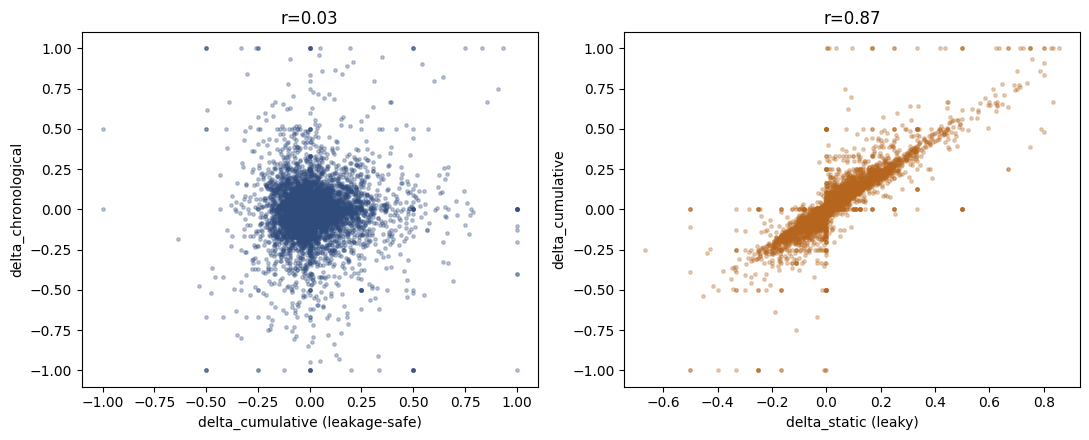

In [4]:
corr = merged[["delta_static", "delta_cumulative", "delta_chronological"]].corr()
print(corr.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(merged["delta_cumulative"], merged["delta_chronological"], s=6, alpha=0.3, color="#2F4B7C")
axes[0].set_xlabel("delta_cumulative (leakage-safe)"); axes[0].set_ylabel("delta_chronological")
axes[0].set_title(f"r={corr.loc['delta_cumulative','delta_chronological']:.2f}")

axes[1].scatter(merged["delta_static"], merged["delta_cumulative"], s=6, alpha=0.3, color="#B5651D")
axes[1].set_xlabel("delta_static (leaky)"); axes[1].set_ylabel("delta_cumulative")
axes[1].set_title(f"r={corr.loc['delta_static','delta_cumulative']:.2f}")
plt.tight_layout()
fig.savefig(FIG / "02_delta_agreement.png", dpi=120)
plt.show()


## 3. Validate delta against an independent discrimination estimate (IRT `a`)

In [5]:
difficulty_outcome_path = OUT / "question_difficulty.csv"
if difficulty_outcome_path.exists():
    irt_out = pd.read_csv(difficulty_outcome_path)[["questions", "irt_discrimination", "D_blend"]]
    val = merged.merge(irt_out, on="questions", how="inner")
    corr_irt = val["delta_cumulative"].abs().corr(val["irt_discrimination"])
    print(f"corr(|delta_cumulative|, IRT discrimination a): {corr_irt:.3f}  (n={len(val)})")
else:
    val = None
    print("NB01 outcome not found yet — run 01_difficulty_irt.ipynb first for the convergent-validity check.")


corr(|delta_cumulative|, IRT discrimination a): -0.076  (n=7217)


A high-discrimination item (large IRT `a`) should show large |delta| — students near
the ability boundary for that item's KCs are the ones whose outcome depends on the item
itself, not just their general skill. A positive correlation here is evidence the
home-grown delta metric is measuring something real, not noise.

## 4. Desirable-difficulty candidate set

In [6]:
if val is not None:
    p_success_proxy = 1 - val["D_blend"]
    candidates = val[
        (p_success_proxy.between(0.70, 0.85)) & (val["irt_discrimination"] > val["irt_discrimination"].median())
    ]
    print(f"{len(candidates)} / {len(val)} items are BOTH in the desirable-difficulty band (success prob 0.70-0.85) "
          f"AND above-median discrimination — the Bandit's ideal candidate pool (RQ3.1).")
    candidates.to_csv(OUT / "desirable_difficulty_candidates.csv", index=False)


18 / 7217 items are BOTH in the desirable-difficulty band (success prob 0.70-0.85) AND above-median discrimination — the Bandit's ideal candidate pool (RQ3.1).


In [7]:
merged.to_csv(OUT / "item_discrimination.csv", index=False)
print(f"saved {len(merged):,} rows to outcomes/item_discrimination.csv")


saved 7,618 rows to outcomes/item_discrimination.csv

In [8]:
with tracking.start_run("02_item_discrimination", "discrimination", params={"n_items": len(merged)}):
    mlflow.log_metric("corr_cumulative_chronological", float(corr.loc["delta_cumulative", "delta_chronological"]))
    mlflow.log_metric("corr_static_cumulative", float(corr.loc["delta_static", "delta_cumulative"]))
    if val is not None:
        mlflow.log_metric("corr_delta_irt_discrimination", float(corr_irt))
        mlflow.log_metric("n_desirable_difficulty_candidates", len(candidates))
    mlflow.log_artifact(str(OUT / "item_discrimination.csv"))
    mlflow.log_artifact(str(FIG / "02_delta_agreement.png"))
print("logged to mlflow")


2026/07/12 02:11:37 INFO mlflow.tracking.fluent: Experiment with name 'noxed-discrimination' does not exist. Creating a new experiment.


2026/07/12 02:11:38 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



logged to mlflow


## Findings → consumed by

- `outcomes/item_discrimination.csv` — reconciled, leakage-safe differentiation metric
  per item, cross-validated against IRT discrimination.
- `outcomes/desirable_difficulty_candidates.csv` → **Bandit** reward (NB08 uses this as
  the ZPD-respecting candidate pool for the reward simulation).
- Resolves an open gap flagged during the codebase audit: the three pre-existing
  differentiation formulations had never been compared to each other or validated.